<a href="https://colab.research.google.com/github/treesajohnangel-arch/fake-news-prediction/blob/main/GradientBoosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline



In [2]:
df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')
df = df[['content', 'label']]

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print("Dataset Shape:", df.shape)
print("\nLabel Distribution:")
print(df['label'].value_counts().rename({0: 'Fake News (0)', 1: 'Real News (1)'}))
df.head()

Dataset Shape: (853, 2)

Label Distribution:
label
Real News (1)    460
Fake News (0)    393
Name: count, dtype: int64


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


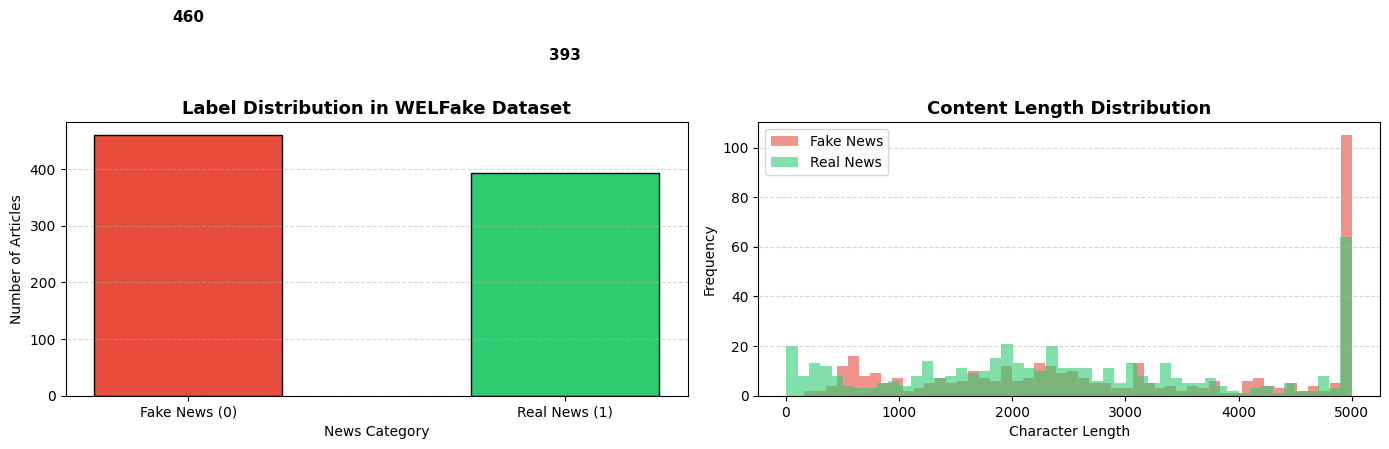

Avg length — Fake: 3816 chars | Real: 3187 chars


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Label Distribution
label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Fake News (0)', 'Real News (1)'], label_counts.values,
            color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Label Distribution in WELFake Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('News Category')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Content Length Distribution
df['content_length'] = df['content'].str.len()
fake_lengths = df[df['label'] == 0]['content_length']
real_lengths = df[df['label'] == 1]['content_length']

axes[1].hist(fake_lengths.clip(upper=5000), bins=50, alpha=0.6, color='#e74c3c', label='Fake News')
axes[1].hist(real_lengths.clip(upper=5000), bins=50, alpha=0.6, color='#2ecc71', label='Real News')
axes[1].set_title('Content Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print(f"Avg length — Fake: {fake_lengths.mean():.0f} chars | Real: {real_lengths.mean():.0f} chars")

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(f'[{re.escape(string.digits)}]', '', text)
    return text.strip()

df['processed_content'] = df['content'].apply(preprocess_text)

print("Preprocessing complete!")
df[['content', 'processed_content']].head(3)

Preprocessing complete!


,content,processed_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...


In [5]:
X = df['processed_content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Train samples  : {X_train_tfidf.shape[0]}")
print(f"Test  samples  : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features: {X_train_tfidf.shape[1]}")

Train samples  : 682
Test  samples  : 171
TF-IDF features: 5000


In [6]:
print("Training Gradient Boosting Classifier...")
print("(Please wait — this may take 10–30 minutes)\n")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train_tfidf, y_train)
print("✅ Model training complete!")

Training Gradient Boosting Classifier...
(Please wait — this may take 10–30 minutes)

✅ Model training complete!


In [7]:
y_pred = gb_model.predict(X_test_tfidf)

label_map = {0: 'Fake', 1: 'Real'}

results_df = pd.DataFrame({
    'Actual_Text_Snippet': X_test.str[:100] + "...",
    'True_Label':          [label_map[i] for i in y_test],
    'Predicted_Label':     [label_map[i] for i in y_pred]
})

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
print("\n--- Predicted vs. True Labels (first 15 samples) ---")
print(results_df.head(15).to_string(index=False))

Model Accuracy: 88.89%

--- Classification Report ---
              precision    recall  f1-score   support

        Fake       0.97      0.78      0.86        77
        Real       0.84      0.98      0.91        94

    accuracy                           0.89       171
   macro avg       0.91      0.88      0.88       171
weighted avg       0.90      0.89      0.89       171


--- Predicted vs. True Labels (first 15 samples) ---
                                                                                     Actual_Text_Snippet True_Label Predicted_Label
 gop lawmaker to trump stop acting like a ‘fragile’ snowflake over town hall protests angry constitue...       Real            Real
 will barack obama delay or suspend the election if hillary is forced out by the new fbi email invest...       Real            Real
 one hilarious tweet perfectly sums up how irrelevant cnn has become nunes dropped a bombshell that o...       Real            Real
 trump says strong europe is importan

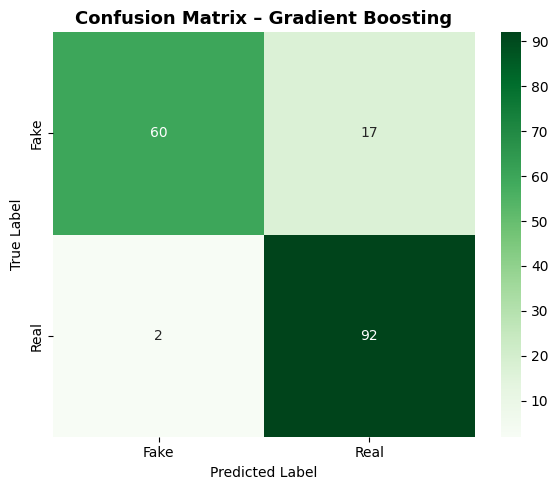

True Positives  (Real → Real): 92
True Negatives  (Fake → Fake): 60
False Positives (Fake → Real): 17
False Negatives (Real → Fake): 2


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix – Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_gb.png', dpi=150)
plt.show()

print(f"True Positives  (Real → Real): {cm[1][1]}")
print(f"True Negatives  (Fake → Fake): {cm[0][0]}")
print(f"False Positives (Fake → Real): {cm[0][1]}")
print(f"False Negatives (Real → Fake): {cm[1][0]}")

Computing Learning Curve (takes a few minutes)...


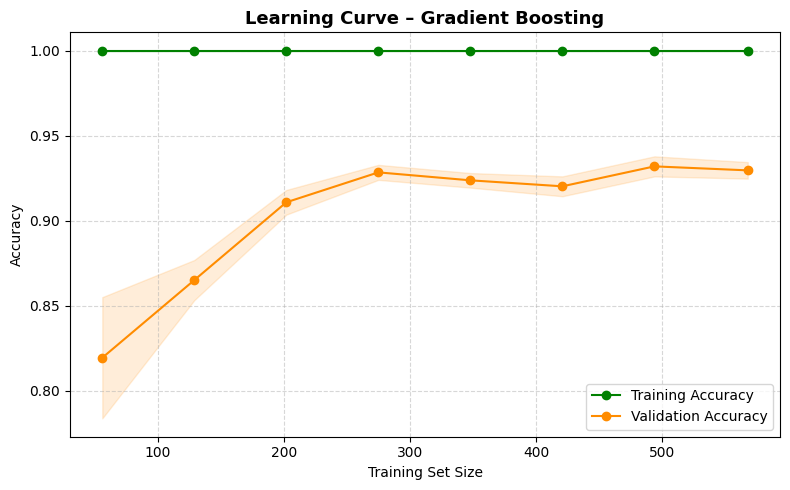

In [9]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   GradientBoostingClassifier(
                  n_estimators=100,
                  learning_rate=0.1,
                  max_depth=3,
                  subsample=0.8,
                  random_state=42))
])

print("Computing Learning Curve (takes a few minutes)...")

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='green',      label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validation Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='green')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='darkorange')
plt.title('Learning Curve – Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('learning_curve_gb.png', dpi=150)
plt.show()

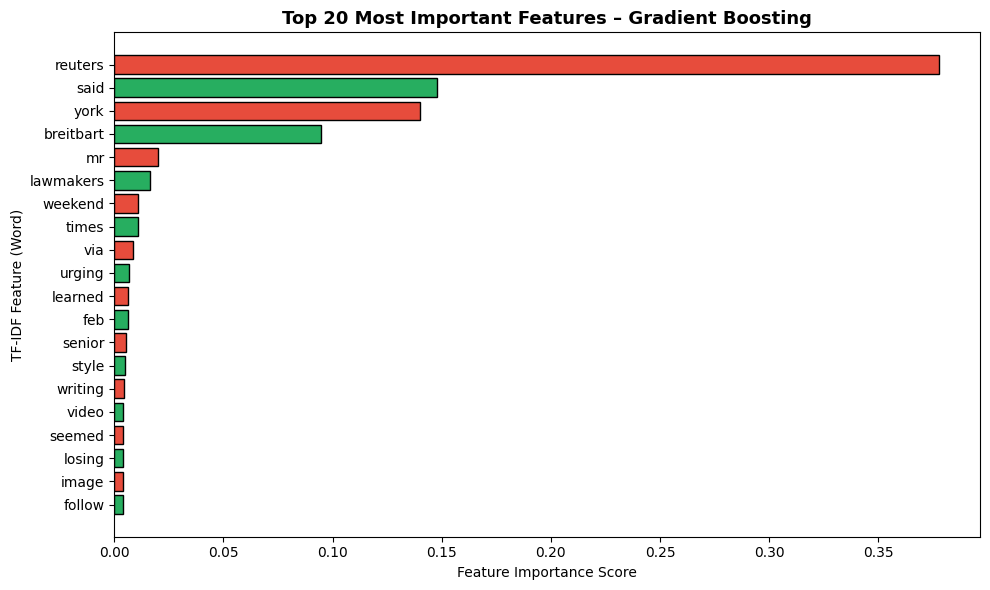

In [10]:
feature_names = vectorizer.get_feature_names_out()
importances   = gb_model.feature_importances_

top_idx      = importances.argsort()[-20:][::-1]
top_features = feature_names[top_idx]
top_scores   = importances[top_idx]

plt.figure(figsize=(10, 6))
colors_bar = ['#e74c3c' if i % 2 == 0 else '#27ae60' for i in range(20)]
plt.barh(top_features[::-1], top_scores[::-1], color=colors_bar[::-1], edgecolor='black')
plt.title('Top 20 Most Important Features – Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('TF-IDF Feature (Word)')
plt.tight_layout()
plt.savefig('feature_importance_gb.png', dpi=150)
plt.show()

In [11]:
print("=" * 50)
print("   GRADIENT BOOSTING — FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"  Dataset        : WELFake Dataset")
print(f"  Total Samples  : {len(df)}")
print(f"  Train Samples  : {len(X_train)}")
print(f"  Test  Samples  : {len(X_test)}")
print(f"  TF-IDF Features: 5000")
print("-" * 50)
print(f"  Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score       : {f1_score(y_test, y_pred):.4f}")
print("=" * 50)
print("  Model Parameters:")
print("    n_estimators  = 100")
print("    learning_rate = 0.1")
print("    max_depth     = 3")
print("    subsample     = 0.8")
print("=" * 50)

   GRADIENT BOOSTING — FINAL RESULTS SUMMARY
  Dataset        : WELFake Dataset
  Total Samples  : 853
  Train Samples  : 682
  Test  Samples  : 171
  TF-IDF Features: 5000
--------------------------------------------------
  Accuracy       : 0.8889
  Precision      : 0.8440
  Recall         : 0.9787
  F1-Score       : 0.9064
  Model Parameters:
    n_estimators  = 100
    learning_rate = 0.1
    max_depth     = 3
    subsample     = 0.8


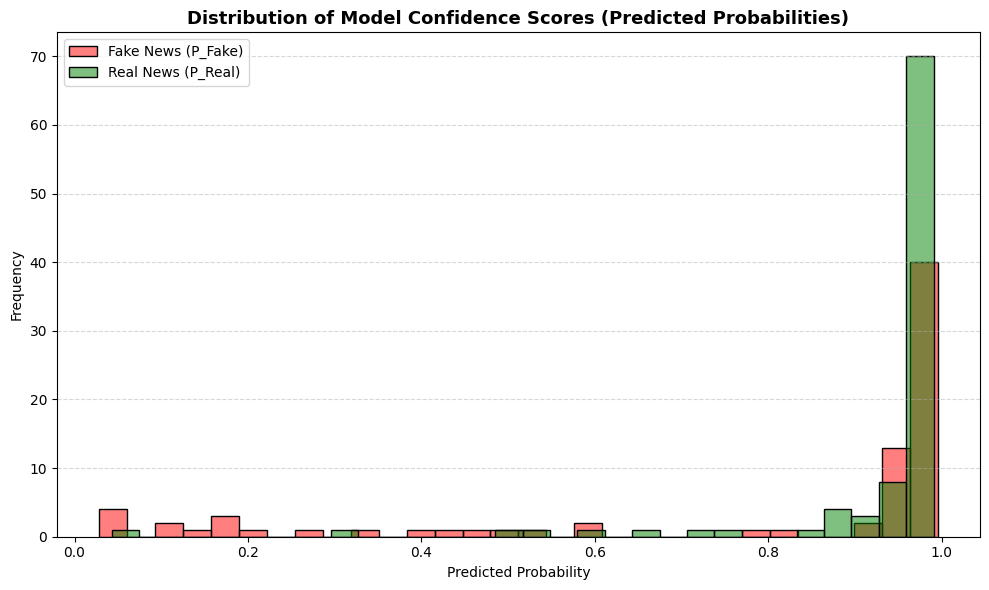

In [12]:
y_pred_proba = gb_model.predict_proba(X_test_tfidf)

# Create a DataFrame for probabilities and true labels
proba_df = pd.DataFrame({
    'True_Label': y_test,
    'Fake_Proba': y_pred_proba[:, 0],
    'Real_Proba': y_pred_proba[:, 1]
})

# Plotting the distribution of confidence scores
plt.figure(figsize=(10, 6))
sns.histplot(proba_df[proba_df['True_Label'] == 0]['Fake_Proba'], color='red', alpha=0.5, bins=30, label='Fake News (P_Fake)')
sns.histplot(proba_df[proba_df['True_Label'] == 1]['Real_Proba'], color='green', alpha=0.5, bins=30, label='Real News (P_Real)')

plt.title('Distribution of Model Confidence Scores (Predicted Probabilities)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('confidence_score_distribution.png', dpi=150)
plt.show()

In [13]:
import joblib
joblib.dump(pipeline, "GradientBoosting_model.pkl")

['GradientBoosting_model.pkl']

In [14]:
from google.colab import files
files.download("GradientBoosting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>